# A robust script to take 2D or 3D output from CESM as well as 2D or 3D ouutput from obs. and reanalysis to:plot
### 1. Zonal Averages for 1D
### 2. Lat-Lon averages for 2D
### 3. Zonal average for 3D
### 4. Lat-lon slices for 2D on a pressure surface 

In [3]:
import xarray as xr
import matplotlib.pyplot as mp
import numpy as np
import glob as glob

import cartopy.crs as ccrs

import importlib
import general_cesm_plot_utils as mypy_utils


In [4]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

cluster = NCARCluster(account='P93300042',interface='mgt', job_extra_directives=[],walltime="12:00:00")
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/ncar_jobqueue/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/38189/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/38189/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.117:41793,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/38189/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
# Replace with your actual file paths and variable name

# Import



dir0 = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'



seas = 'ANN'

lfcase = True
lanom_plot = True


plot_type = "latlon" # lat/latlon,latpres

mask_ocn = False


pregion = 'IO'

if lfcase:

    fig_pref = 'CAM7'

    dcases = {'CAM7'               : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.002',
             '0.75*lhf'           : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001',
             'qsat (T2m)'         : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001',
             'flux all (T2m)'     : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001',
             'flux all (T2m:SST)' :'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001',
             'UA'                 :'f.e30_cam6_4_078.FHISTC_LTso.ne30.ocnflx2_roughphis_SGH_grlnd28k.001',
             'G&G qsat'           :'f.e30_cam6_4_078.FHISTC_LTso.ne30.baseline156_qsat.001'}

else:

    fig_pref = 'CESM3'
    
    dcases = {'156': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156', 
              '158': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.158',
              '160': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160', 
              '162': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.162', 
              '163': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163',
              '164': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163'}
   
    
case_names = list(dcases.keys())
cases = [v for v in dcases.values()]


#var = 'SHFLX' ; vdesc = 'Sensible Heat Flux'  ; vscale = 1. ; vunits = 'W/m^2' ; obs_cases = ['JRA25']
#var = 'LHFLX' ; vdesc = 'Latent Heat Flux'  ; vscale = 1. ; vunits = 'W/m^2' ; obs_cases = ['ERAI', 'LARYEA','WHOI']
var = 'PRECT' ; vname = 'Total Precipitation' ; vscale = 86400.*1000. ; vunits = 'mm/day'; obs_cases = ['GPCP', 'TRMM']
#var = 'TMQ' ; vdesc = 'Precipitable Water' ; vscale = 1. ; vunits = 'mm'; obs_cases=['NVAP']
#var = 'TAUX' ; vdesc = 'Zonal Surface Stress' ; vscale = 1. ; vunits = 'N/m^2'; obs_cases=['MERRA','JRA25','ERS']
#var = 'TAUY' ; vdesc = 'Meridonal Surface Stress' ; vscale = 1. ; vunits = 'N/m^2'; obs_cases=['MERRA','JRA25','ERS']


vmask_ocn = ['SHFLX','LHFLX','TMQ','TAUX','TAUY']


cases = obs_cases+cases
case_names = obs_cases+case_names

ncases = len(cases)


obs_set = ['GPCP','TRMM','ERAI','JRA25','MERRA','LARYEA','WHOI','NVAP','ERS','SSMI']


# Set plot set logicals


lplat_ave = True if plot_type == 'lat' else False
lplatlon_ave = True if plot_type == 'latlon' else False
lplatpres_ave = True if plot_type == 'latpres' else False




Plotting  PRECT for the following cases
- GPCP
- TRMM
- f.cam6_4_032.FLTHIST_ne30.cam7_dev.002
- f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.ocnflx2_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.baseline156_qsat.001

Case -  [1]  of  [9]  -  GPCP
- Open Dataset -

Case -  [2]  of  [9]  -  TRMM
- Open Dataset -

Case -  [3]  of  [9]  -  f.cam6_4_032.FLTHIST_ne30.cam7_dev.002
- Open Dataset -

Case -  [4]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001
- Open Dataset -

Case -  [5]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001
- Open Dataset -

Case -  [6]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_

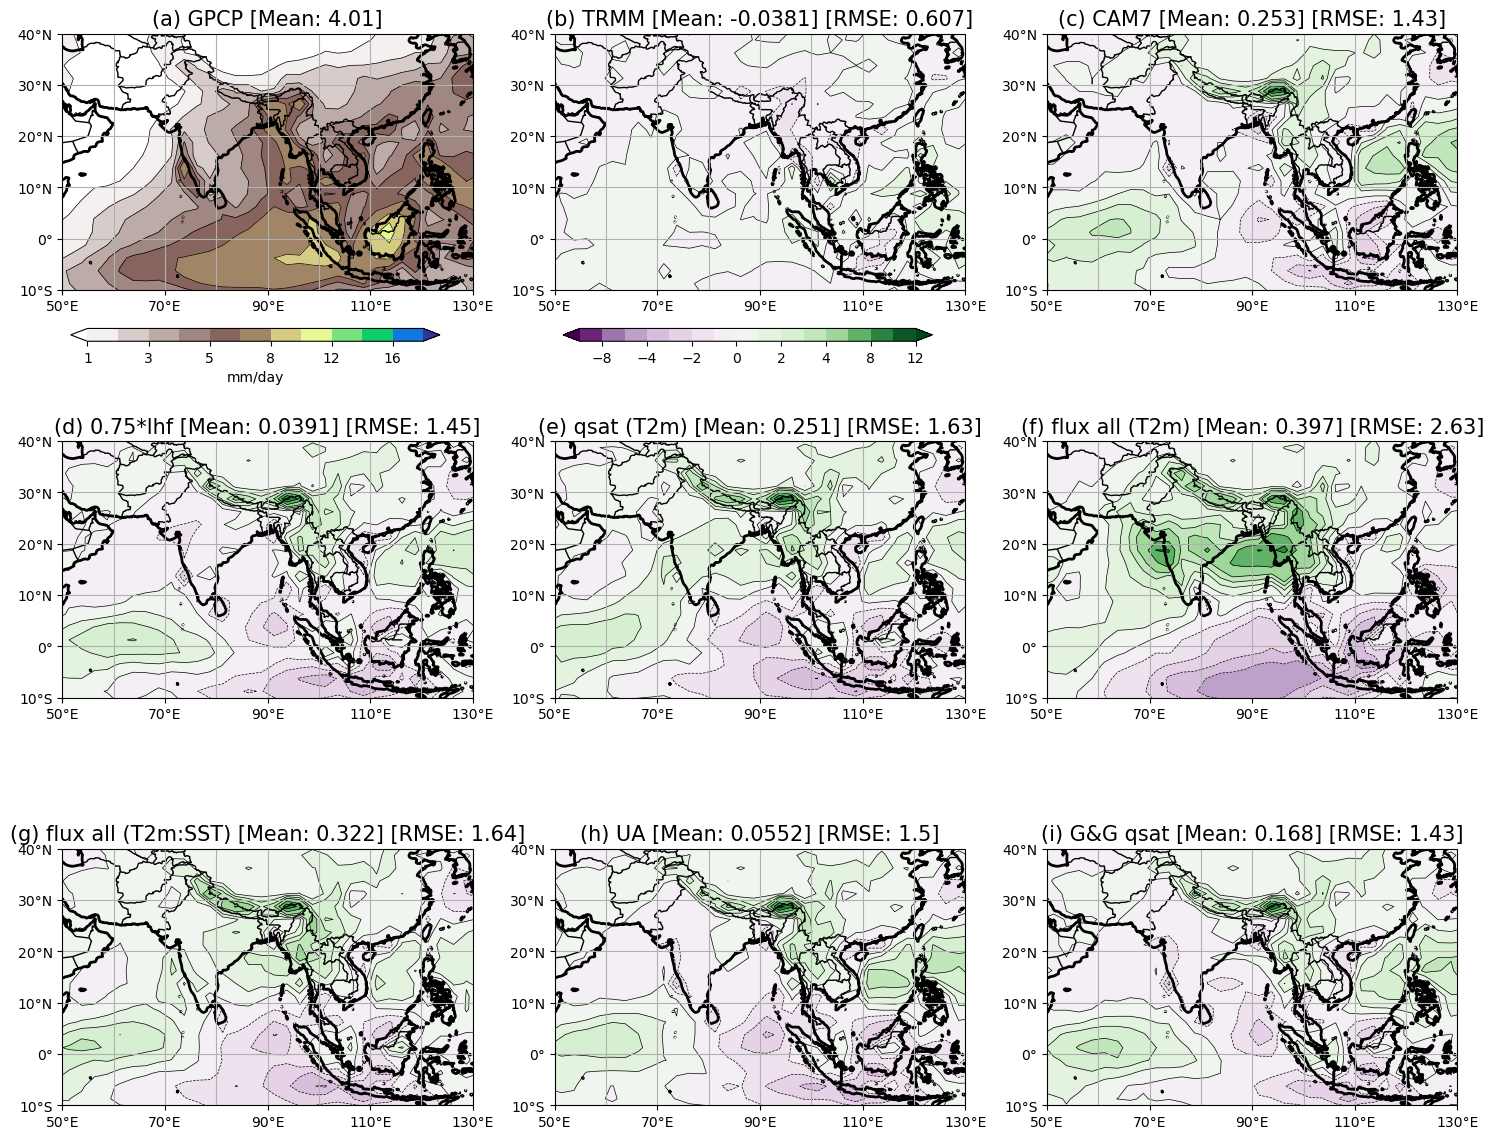

In [6]:
importlib.reload(mypy_utils) # Required because I am constantly editing scam_func.py


if lplat_ave:
    fig, ax = mp.subplots(figsize=[10, 6])    
    

if lplatlon_ave:
    nrows = 3
    ncols = 3
    
    
    fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*5],
                           subplot_kw={'projection': ccrs.PlateCarree()})    
    ax = axs.flatten()

if lplatpres_ave:
    
    nrows = 3
    ncols = 3
    
    fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*5],
                           subplot_kw={'projection': ccrs.PlateCarree()})    
    ax = axs.flatten()




if nrows*ncols > ncases:
        print(" Insufficient planels for ncases")



print('Plotting ',var,'for the following cases')
fcases = '\n'.join(f"- {item}" for item in cases)

print(fcases)








''' LOOP CASES '''


for icase, case in enumerate(cases):
   
    print('')
    print('Case - ',[icase+1],' of ',[ncases],' - ',case)
    cname = case_names[icase]
    llast_case = icase == ncases-1 # Is this the last case.


# Obs and 2 climo types file selection.
    if case in obs_set:
        case_file = dir_obs+case+'_'+seas+'_climo.nc'        
    else:
        if 'b.e30' in case:
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_'+var+'_climo.nc')[0]  
        else:
            case_file = dir0+case+'/climo/'+case+'_'+seas+'_climo.nc'
            

# Open dataset

    print('- Open Dataset -')
    ds = xr.open_dataset(case_file,decode_times = False)
    
    
# Extract variable/obs. specific information

    var_info = mypy_utils.set_var_params(var,case)
    
    var_on_file = var_info[var][case][1] if case in obs_set else var
    vscale = var_info[var][case][0]      if case in obs_set else var_info[var]['vscale']
    vunits = var_info[var]['vunits']


  
# Select climo files (2 types - amwg/python versions)
    if ds.sizes.get('time') == 12:
        mon_index = putil.get_indexes(seas)
        ds = ds.sel(time=mon_index).mean(dim='time').squeeze()
    
    var_in = ds[var_on_file].isel(time=0) if 'time' in ds[var_on_file].dims else ds[var_on_file]
    var_in = var_in*vscale


# Masking option (later) 
#    if icase == 0:  
#        if 'b.e30' in case:
#            case_file = glob.glob(dir_climo+case+'/*/'+case+'_LANDFRAC_climo.nc')[0]  
#            
#            dlfrac = xr.open_dataset(case_file,decode_times = False)
#            lmask = dlfrac['LANDFRAC'].isel(time=0) 
#        else:
#            lmask =  ds['LANDFRAC'].isel(time=0) if 'time' in ds['LANDFRAC'].dims else ds['LANDFRAC']

    if var in vmask_ocn:
      
        mask_ocn = True
        lmaski = lmask.interp_like(var_in)
        var_in = var_in.where(lmaski < 0.1)  # or lsm == False if it's a boolean mask
        

# Anomalies from icase = 0?

    if icase == 0 and lanom_plot: 
        var_save = var_in
        var_plot = var_in
    if icase >0 and lanom_plot:
        var_plot = var_in.interp_like(var_save)-var_save
    if not lanom_plot:
        var_plot = var_in
    
    
    
# Plotting options
    
    if lplat_ave:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_lat(icase,case,obs_set)
        mypy_utils.plot_lat(ax,fig,zonal_mean,vunits,cname,seas,mask_ocn,llast_case,params_plot)

    if lplatlon_ave:
        params_plot = mypy_utils.set_params_latlon(icase,ncases,var,obs_set,lanom_plot)
        mypy_utils.plot_latlon(ax[icase],fig,icase,var_plot,vunits,cname,seas,pregion,mask_ocn,lanom_plot,llast_case,params_plot)

    if lplatpres_ave:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_latpres(icase,ncases,case,cases,obs_set)
        mypy_utils.plot_latpres(ax[icase],fig,var_plot,vunits,cname,seas,mask_ocn,llast_case,params_plot)
        
# Set unused ax[icase] to blank
for ix in range(ncases,nrows*ncols): ax[ix].set_visible(False)
    
    


